In [18]:
import pandas as pd
import cv2 as cv
import cvTools.interaction as cvt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Whole dataset

In [2]:
feats = pd.read_csv('data/features.csv', index_col='image', dtype={'height':int, 'width':int, 'feat_num':int}).sort_index()
labels = pd.read_csv('data/ISIC_2019_GroundTruth.csv', index_col='image', usecols=['image', 'MEL'], dtype={'MEL':bool}).sort_index()
feats_train, feats_val_test, labels_train, labels_val_test = train_test_split(feats, labels, train_size=.8, random_state=42)
feats_val, feats_test, labels_val, labels_test = train_test_split(feats_val_test, labels_val_test, train_size=.66, random_state=42)

In [83]:
forest = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, class_weight='balanced')
forest.fit(feats_train.values, labels_train.values.squeeze())

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [84]:
print('Confusion Matrix\n', confusion_matrix(labels_train.values.squeeze(), forest.predict(feats_train.values), normalize='true'))
print('Confusion Matrix\n', confusion_matrix(labels_val.values.squeeze(), forest.predict(feats_val.values), normalize='true'))

Confusion Matrix
 [[0.8668349  0.1331651 ]
 [0.13669065 0.86330935]]
Confusion Matrix
 [[0.81529412 0.18470588]
 [0.30033557 0.69966443]]


In [80]:
print('Confusion Matrix\n', confusion_matrix(labels_train.values.squeeze(), forest.predict(feats_train.values), normalize='true'))
print('Confusion Matrix\n', confusion_matrix(labels_val.values.squeeze(), forest.predict(feats_val.values), normalize='true'))

Confusion Matrix
 [[0.86848491 0.13151509]
 [0.13752075 0.86247925]]
Confusion Matrix
 [[0.82705882 0.17294118]
 [0.32550336 0.67449664]]


In [60]:
# n_est=50, max_depth=5
print('Confusion Matrix\n', confusion_matrix(labels_train.values.squeeze(), forest.predict(feats_train.values), normalize='true'))
print('Confusion Matrix\n', confusion_matrix(labels_val.values.squeeze(), forest.predict(feats_val.values), normalize='true'))

Confusion Matrix
 [[0.71328739 0.28671261]
 [0.22108467 0.77891533]]
Confusion Matrix
 [[0.70176471 0.29823529]
 [0.23154362 0.76845638]]


In [58]:
# n_est=50, max_depth=10
print('Confusion Matrix\n', confusion_matrix(labels_train.values.squeeze(), forest.predict(feats_train.values), normalize='true'))
print('Confusion Matrix\n', confusion_matrix(labels_val.values.squeeze(), forest.predict(feats_val.values), normalize='true'))

Confusion Matrix
 [[0.87100844 0.12899156]
 [0.13143331 0.86856669]]
Confusion Matrix
 [[0.81823529 0.18176471]
 [0.30033557 0.69966443]]


In [16]:
feats.columns

Index(['L_m', 'L_s', 'A_m', 'A_s', 'B_m', 'B_s', 'height', 'width', 'ver_symm',
       'hor_symm', 'cent_symm', 'feat_num'],
      dtype='object')

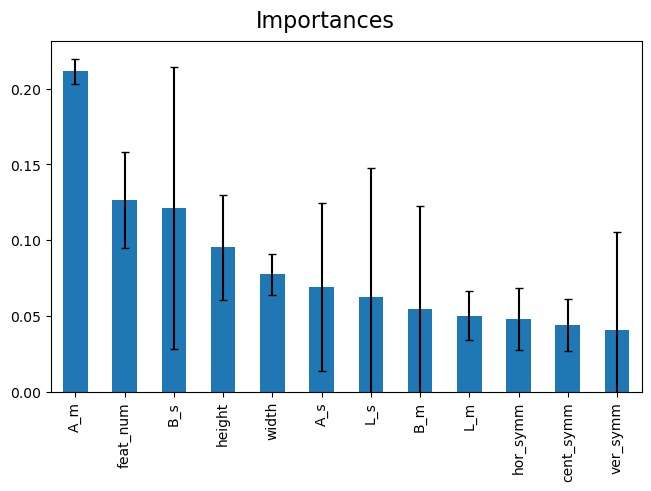

In [85]:
fig, ax = plt.subplots(layout='constrained')
fig.suptitle('Importances', fontsize=16)

importances = pd.Series(forest.feature_importances_, index=list(feats.columns)).sort_values(ascending=False)
importances.plot.bar(yerr=np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0), capsize=3, ax=ax)
ax.set_ylim(0)
plt.show()


# Reduced
4522 # MEL

In [94]:
sel_NV = labels[labels['MEL']==False].sample(n=4522, random_state=42)

In [132]:
labels_red = pd.concat([labels[labels['MEL']==True], sel_NV]).sort_index()
feats_red = feats.loc[labels_red.index]
feats_train, feats_val_test, labels_train, labels_val_test = train_test_split(feats_red, labels_red, train_size=.8, random_state=42)
feats_val, feats_test, labels_val, labels_test = train_test_split(feats_val_test, labels_val_test, train_size=.66, random_state=42)

In [149]:
forest = RandomForestClassifier(n_estimators=100, max_depth=None, n_jobs=-1)
forest.fit(feats_train.values, labels_train.values.squeeze())

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [150]:
# n_estimators 100
print('Confusion Matrix\n', confusion_matrix(labels_train.values.squeeze(), forest.predict(feats_train.values), normalize='true'))
print('Confusion Matrix\n', confusion_matrix(labels_val.values.squeeze(), forest.predict(feats_val.values), normalize='true'))

Confusion Matrix
 [[1.00000000e+00 0.00000000e+00]
 [2.74423710e-04 9.99725576e-01]]
Confusion Matrix
 [[0.7902439  0.2097561 ]
 [0.24567474 0.75432526]]


In [134]:
# 50
print('Confusion Matrix\n', confusion_matrix(labels_train.values.squeeze(), forest.predict(feats_train.values), normalize='true'))
print('Confusion Matrix\n', confusion_matrix(labels_val.values.squeeze(), forest.predict(feats_val.values), normalize='true'))

Confusion Matrix
 [[1.00000000e+00 0.00000000e+00]
 [2.74423710e-04 9.99725576e-01]]
Confusion Matrix
 [[0.79186992 0.20813008]
 [0.25259516 0.74740484]]


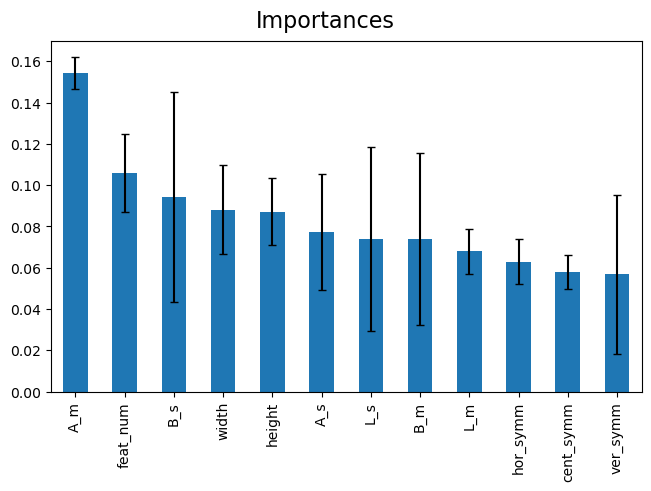

In [151]:
fig, ax = plt.subplots(layout='constrained')
fig.suptitle('Importances', fontsize=16)

importances = pd.Series(forest.feature_importances_, index=list(feats.columns)).sort_values(ascending=False)
importances.plot.bar(yerr=np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0), capsize=3, ax=ax)
ax.set_ylim(0)
plt.show()
